# 03 — Scenariusz kolizyjny fazy online (avoidance)

**Cel.** Symulacja scenariusza, w którym główny rój leci prostoliniowo,
a *dynamiczne przeszkody* nadlatują czołowo (head-on). Notebook wywołuje
pełen pipeline z `main.py` w trybie headless i wykorzystując wybrany
algorytm fazy online (`avoidance=msffoa|ooa|ssa|nsga-3`). Wyniki —
trajektorie i zdarzenia uniku — są wczytywane bezpośrednio z plików
CSV i wizualizowane.

**Dlaczego subprocess?** Pełen run online avoidance wymaga PyBullet,
LiDAR (numba JIT), `SwarmFlightController` (FSM z trybami `TRACKING ⇄
EVASION ⇄ REJOIN_BLEND`) oraz fizyki kontaktowej. Najwierniejszą
reprezentacją scenariusza jest uruchomienie `python main.py` z
`subprocess.run`. Notebook parsuje katalog wynikowy (`results/<data>/...`)
i renderuje wykres.

**Co i jak edytować?**

* `AVOIDANCE_NAME` — algorytm fazy online (`'msffoa'`, `'ooa'`, `'ssa'`, `'nsga-3'`).
* `DURATION_SEC` — czas symulacji (krótki run = ~6–10 s realnego lotu).
* `MASTER_SEED` — ziarno; różne ziarna ⇒ inne pozycje pierwszego trygera.
* `DRONE_TO_PLOT` — indeks drona do szczegółowego wykresu (0..1 dla empty).

**Geometria head-on.** Środowisko `empty` ma 2 drony lecące Y: 1 → 99 m
(X=15 i X=20), a `simulation.dynamic_obstacles=True` ⇒ 2 dynamiczne
przeszkody startują w `end_xyzs` dronów i lecą do `initial_xyzs` —
czyli idealnie czołowo, na tej samej wysokości.

In [1]:
import prepare_notebook  # noqa: F401

Dodano do ścieżki: /home/edwinh/drone-swarm-simulation


In [2]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# PARAMETRY DO EDYCJI
# ---------------------------------------------------------------------------
AVOIDANCE_NAME: str = "msffoa"   # 'msffoa' | 'ooa' | 'ssa' | 'nsga-3'
OPTIMIZER_NAME: str = "msffoa"   # optymalizator offline (planowanie trasy bazowej)
DURATION_SEC: int = 8            # czas misji [s] — krótki run dla notebooka
MASTER_SEED: int = 43
DRONE_TO_PLOT: int = 0           # indeks drona do szczegółowego wykresu

PROJECT_ROOT = Path(prepare_notebook.project_root)
MAIN_PY = PROJECT_ROOT / "main.py"
assert MAIN_PY.exists(), MAIN_PY

In [3]:
# Wywołanie pipeline'u z drastycznie zredukowanymi parametrami optymalizatora
# offline — interesuje nas faza online (avoidance), nie jakość trasy bazowej.
overrides = [
    "environment=empty",
    f"optimizer={OPTIMIZER_NAME}",
    f"avoidance={AVOIDANCE_NAME}",
    "simulation.gui=false",
    "simulation.dynamic_obstacles=true",
    f"simulation.duration_sec={DURATION_SEC}",
    f"seed={MASTER_SEED}",
    "optimizer.algorithm_params.pop_size=16",
    "optimizer.algorithm_params.epochs=5",
    "logging.enabled=true",
    "experiment_name=notebook03_collision_scenario",
]
# NSGA-III używa innego klucza budżetu — `n_gen` zamiast `epochs`.
if OPTIMIZER_NAME == "nsga-3":
    overrides = [o for o in overrides if not o.startswith("optimizer.algorithm_params.epochs")]
    overrides.append("optimizer.algorithm_params.n_gen=5")

cmd = [sys.executable, str(MAIN_PY), *overrides]
print("Komenda:", " ".join(cmd))

Komenda: /home/edwinh/miniconda3/envs/drone-swarm-env/bin/python /home/edwinh/drone-swarm-simulation/main.py environment=empty optimizer=msffoa avoidance=msffoa simulation.gui=false simulation.dynamic_obstacles=true simulation.duration_sec=8 seed=43 optimizer.algorithm_params.pop_size=16 optimizer.algorithm_params.epochs=5 logging.enabled=true experiment_name=notebook03_collision_scenario


In [4]:
# Uwaga: pierwszy run kompiluje numba JIT (~10–30 s).
proc = subprocess.run(
    cmd,
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
    env={**os.environ, "PYTHONUNBUFFERED": "1"},
)
print("Return code:", proc.returncode)
print("--- ostatnie 30 linii stdout ---")
print("\n".join(proc.stdout.splitlines()[-30:]))
if proc.returncode != 0:
    print("--- stderr ---")
    print("\n".join(proc.stderr.splitlines()[-30:]))
    raise RuntimeError("Symulacja zakończona błędem.")

Return code: 0
--- ostatnie 30 linii stdout ---
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[DEBUG] _actionSpace()
[DEBUG] _observationSpace()
[DEBUG] Deleting default plane...
[DEBUG] Setting up environment...
[DEBUG] _create_ground()
[DEBUG] Ground created (100.0x30.0)
[DEBUG] _create_ceiling()
[DEBUG] Ceiling created at height 12.0m
[DEBUG] Environment setup complete.
[DEBUG]: SwarmBaseWorld init_render_silently()
[DEBUG] Generating empty environment...
[DEBUG]: SwarmBaseWorld finalize_render()
[DEBUG] Start symulacji na 384 kroków (z dynamicznych przeszkód).
[INFO] Postęp: 38/384 (10%)
[INFO] Postęp: 76/384 (20%)
[INFO] Postęp: 114/384 (30%)
[INFO] Postęp: 152/384 (40%)
[INFO] Postęp: 190/384 (49%)
[INFO] Postęp: 228/384 (59%)
[INFO] Postęp: 266/384 (69%)
[INFO] Postęp: 304/384 (79%)
[INFO] Postęp: 342

In [6]:
# Znajdź najnowszy katalog wynikowy (`results/<YYYY-MM-DD>/<HH-MM-SS>_empty_<opt>`).
RESULTS_ROOT = PROJECT_ROOT / "results"
candidates = sorted(
    (p for p in RESULTS_ROOT.rglob("*_empty_*") if (p / "trajectories.csv").exists()),
    key=lambda p: p.stat().st_mtime,
)
assert candidates, f"Nie znaleziono żadnego runa empty pod {RESULTS_ROOT}"
run_dir = candidates[-1]
print(f"Run dir: {run_dir}")
print("Zawartość:", sorted(p.name for p in run_dir.iterdir()))

Run dir: /home/edwinh/drone-swarm-simulation/results/2026-05-15/02-06-59_empty_msffoa
Zawartość: ['.hydra', 'counted_trajectories.csv', 'main.log', 'optimization_history', 'optimization_timings.csv', 'trajectories.csv', 'world_boundaries.csv']


In [7]:
# Wczytanie trajektorii i (jeśli istnieją) zdarzeń uniku.
traj = pd.read_csv(run_dir / "trajectories.csv")
print(f"Trajektorie: {len(traj)} próbek, {traj['drone_id'].nunique()} dronów")

evasion_path = run_dir / "evasion_events.csv"
if evasion_path.exists() and evasion_path.stat().st_size > 0:
    evasion = pd.read_csv(evasion_path)
    print(f"Zdarzenia uniku: {len(evasion)}")
else:
    evasion = pd.DataFrame()
    print("Brak zarejestrowanych zdarzeń uniku.")

collisions_path = run_dir / "collisions.csv"
if collisions_path.exists() and collisions_path.stat().st_size > 0:
    collisions = pd.read_csv(collisions_path)
    print(f"Kolizje: {len(collisions)}")
else:
    collisions = pd.DataFrame()

Trajektorie: 16 próbek, 2 dronów
Brak zarejestrowanych zdarzeń uniku.


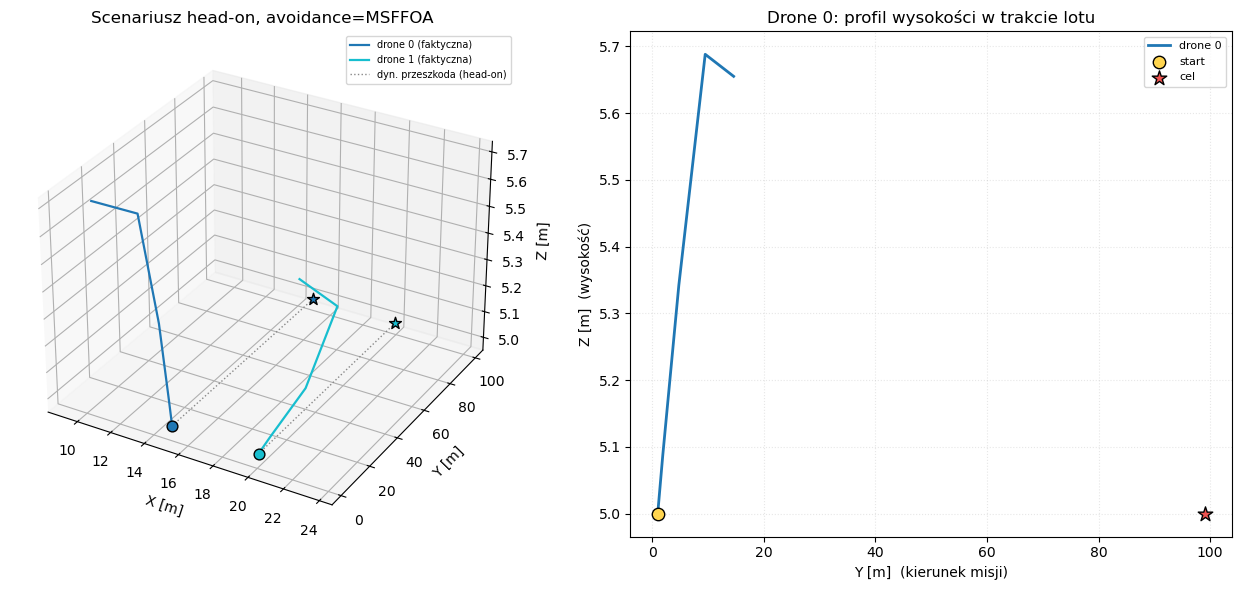

In [11]:
# Rysunek 1: pełen widok 3D wszystkich dronów + przeszkody dynamiczne (rekonstrukcja
# czołowa). Trasa dynamicznych przeszkód = trasa drugiego drona w odwrotnym
# kierunku (nie logujemy ich osobno, ale znamy geometrię z `empty.yaml`).
import yaml
with (PROJECT_ROOT / "configs/environment/empty.yaml").open() as f:
    env_cfg = yaml.safe_load(f)
start_positions = np.asarray(env_cfg["initial_xyzs"])
target_positions = np.asarray(env_cfg["end_xyzs"])

fig = plt.figure(figsize=(13, 6))
ax3d = fig.add_subplot(121, projection="3d")
colors = plt.cm.tab10(np.linspace(0, 1, traj["drone_id"].nunique()))

for d_id, sub in traj.groupby("drone_id"):
    ax3d.plot(sub["x"], sub["y"], sub["z"], color=colors[d_id],
              linewidth=1.6, label=f"drone {d_id} (faktyczna)")
    ax3d.scatter(start_positions[d_id, 0], start_positions[d_id, 1], start_positions[d_id, 2],
                 color=colors[d_id], s=60, marker="o", edgecolor="black")
    ax3d.scatter(target_positions[d_id, 0], target_positions[d_id, 1], target_positions[d_id, 2],
                 color=colors[d_id], s=80, marker="*", edgecolor="black")

# Schematyczne strzałki dynamicznych przeszkód (head-on relative).
for d_id in range(len(start_positions)):
    obs_start = target_positions[d_id]
    obs_end = start_positions[d_id]
    ax3d.plot([obs_start[0], obs_end[0]],
              [obs_start[1], obs_end[1]],
              [obs_start[2], obs_end[2]],
              color="#888", linestyle=":", linewidth=1.0,
              label="dyn. przeszkoda (head-on)" if d_id == 0 else None)

ax3d.set_xlabel("X [m]"); ax3d.set_ylabel("Y [m]"); ax3d.set_zlabel("Z [m]")
ax3d.set_title(f"Scenariusz head-on, avoidance={AVOIDANCE_NAME.upper()}")
ax3d.legend(loc="upper right", fontsize=7)

# Rysunek 2: rzut Y-Z (oś misji vs. wysokość) dla wybranego drona —
# wyraźnie widać manewr uniku w pionie/poziomie.
ax2 = fig.add_subplot(122)
sub = traj[traj["drone_id"] == DRONE_TO_PLOT].sort_values("time")
ax2.plot(sub["y"], sub["z"], color=colors[DRONE_TO_PLOT], linewidth=2.0,
         label=f"drone {DRONE_TO_PLOT}")
ax2.scatter([start_positions[DRONE_TO_PLOT, 1]], [start_positions[DRONE_TO_PLOT, 2]],
            c="#ffd54f", s=80, edgecolor="black", zorder=5, label="start")
ax2.scatter([target_positions[DRONE_TO_PLOT, 1]], [target_positions[DRONE_TO_PLOT, 2]],
            c="#ef5350", s=120, marker="*", edgecolor="black", zorder=5, label="cel")

if not evasion.empty:
    ev_d = evasion[evasion["drone_id"] == DRONE_TO_PLOT]
    starts = ev_d[ev_d["event_type"] == "PLAN_START"] if "event_type" in ev_d else ev_d
    for _, row in starts.iterrows():
        ax2.axvline(row.get("threat_y", np.nan), color="gray", linestyle="--", alpha=0.4)
        ax2.scatter([row.get("threat_y", np.nan)], [row.get("threat_z", np.nan)],
                    marker="x", color="red", s=80,
                    label="threat @ trigger" if "threat @ trigger" not in ax2.get_legend_handles_labels()[1] else None)

ax2.set_xlabel("Y [m]  (kierunek misji)")
ax2.set_ylabel("Z [m]  (wysokość)")
ax2.grid(True, alpha=0.3, linestyle=":")
ax2.legend(loc="best", fontsize=8)
ax2.set_title(f"Drone {DRONE_TO_PLOT}: profil wysokości w trakcie lotu")

plt.tight_layout()
plt.show()

In [12]:
# Tabela podsumowująca zdarzenia uniku dla wybranego drona.
if not evasion.empty:
    cols = [c for c in ["time", "event_type", "mode", "ttc", "dist_to_threat",
                          "preferred_axis", "fallback_used", "planning_wall_time_s"]
              if c in evasion.columns]
    display(evasion[evasion["drone_id"] == DRONE_TO_PLOT][cols].head(10))
else:
    print("Brak danych do podsumowania — symulacja nie wyzwoliła żadnego uniku.")

Brak danych do podsumowania — symulacja nie wyzwoliła żadnego uniku.


## Notatka metodologiczna

Notebook ilustruje *podstawowy* scenariusz head-on z 2 dronami
i 2 dynamicznymi przeszkodami w środowisku `empty`. W pełnych
eksperymentach (`results/exp_20260508_f3f718f8_bio_inspired_benchmark`)
scenariusz był testowany w `forest` i `urban` z 5 dronami + 5 dynamicznymi
przeszkodami i 30 ziarnami (zob. `appendix/INDEX.md`).

Mechanika uniku (`GenericOptimizingAvoidance`) jest kompozycją 4
wymienialnych sub-strategii — patrz diagram klas w
`src/algorithms/ALGORITHMS.md`. Czteroma głównymi algorytmami online są
MSFOA, OOA, SSA i NSGA-III; wszystkie używają identycznego budżetu
czasu (`time_budget_s = 0.5 s` + `hard_kill_factor`).

**Uwaga.** Pierwszy run kompiluje funkcje `@njit` z Numby — kolejne
uruchomienia w tym samym środowisku są znacznie szybsze (~5×).